# Assignment 3 — From Raw Signals to a Lean Feature Set

**Course:** Feature Engineering & MLOps  
**Assignment No.:** 3  
**Topic:** Time-based Features, Feature Creation & Feature Selection

This assignment creates time-based and interaction features, then applies filter, wrapper, and embedded feature-selection methods to identify a lean feature set.

In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.feature_selection import VarianceThreshold, RFE, mutual_info_regression
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

## Load and Sort the Dataset

In [19]:
candidate_paths = [
    "/content/daily_batch_performance.csv"
]

DATA_PATH = next((p for p in candidate_paths if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError("daily_batch_performance.csv not found.")

df = pd.read_csv(DATA_PATH, parse_dates=["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Shape:", df.shape)
display(df.head())

Shape: (730, 10)


,date,marketing_spend,discount_pct,website_visits,website_visits_copy,competitor_promo_flag,is_holiday,random_noise_1,random_noise_2,new_enrollments
0,2024-01-01,9069.0000,10,561.0000,567.0000,1,1,60.6000,A,20
1,2024-01-02,6573.0000,10,559.0000,570.0000,1,1,82.9000,C,23
2,2024-01-03,14636.0000,0,539.0000,554.0000,0,0,41.9000,A,29
3,2024-01-04,3979.0000,5,574.0000,557.0000,0,0,44.4000,B,30
4,2024-01-05,9654.0000,10,661.0000,661.0000,0,0,23.8000,B,38


# 4.1 — Phase 3: Time-based Features & Feature Creation

### 1. Target over time

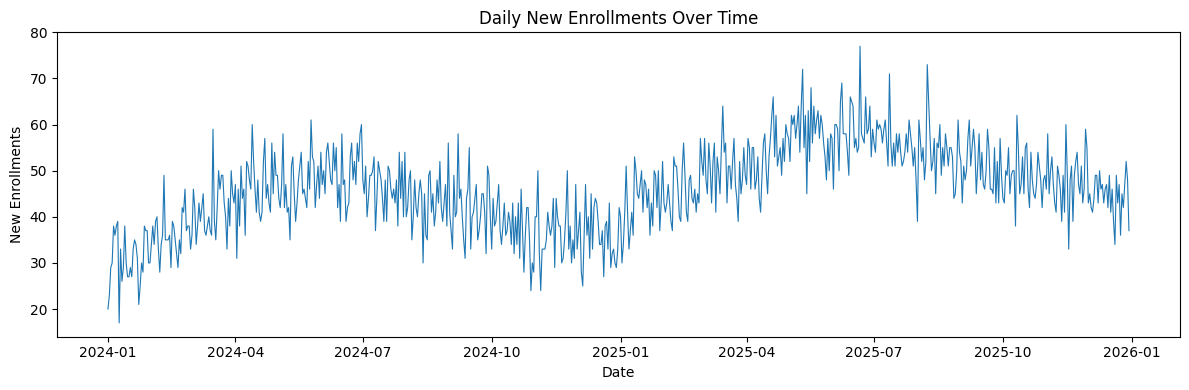

In [20]:
plt.figure(figsize=(12, 4))
plt.plot(df["date"], df["new_enrollments"], linewidth=0.8)
plt.title("Daily New Enrollments Over Time")
plt.xlabel("Date")
plt.ylabel("New Enrollments")
plt.tight_layout()
plt.show()

**Pattern by eye:** `new_enrollments` shows a gradual upward trend with a repeating weekly pattern.

### 2. Lag features

In [21]:
df["marketing_spend_lag1"] = df["marketing_spend"].shift(1)
df["marketing_spend_lag2"] = df["marketing_spend"].shift(2)

corr_table = pd.DataFrame({
    "feature": [
        "marketing_spend",
        "marketing_spend_lag1",
        "marketing_spend_lag2"
    ],
    "correlation": [
        df["marketing_spend"].corr(df["new_enrollments"]),
        df["marketing_spend_lag1"].corr(df["new_enrollments"]),
        df["marketing_spend_lag2"].corr(df["new_enrollments"])
    ]
})

display(corr_table)

strongest = corr_table.loc[
    corr_table["correlation"].abs().idxmax(), "feature"
]
print("Strongest:", strongest)

,feature,correlation
0,marketing_spend,0.1189
1,marketing_spend_lag1,-0.0092
2,marketing_spend_lag2,0.2184


Strongest: marketing_spend_lag2


**Result:** `marketing_spend_lag2` has the strongest relationship with `new_enrollments`. This makes sense because advertising can take a couple of days to convert into student enquiries or walk-ins.

### 3. Rolling features

In [22]:
df["enroll_roll_mean_7"] = df["new_enrollments"].rolling(7).mean()
df["enroll_roll_std_7"] = df["new_enrollments"].rolling(7).std()

display(
    df[["date", "new_enrollments", "enroll_roll_mean_7", "enroll_roll_std_7"]].head(10)
)

,date,new_enrollments,enroll_roll_mean_7,enroll_roll_std_7
0,2024-01-01,20,NaN,NaN
1,2024-01-02,23,NaN,NaN
2,2024-01-03,29,NaN,NaN
3,2024-01-04,30,NaN,NaN
4,2024-01-05,38,NaN,NaN
5,2024-01-06,36,NaN,NaN
6,2024-01-07,38,30.5714,7.2078
7,2024-01-08,39,33.2857,6.0474
8,2024-01-09,17,32.4286,7.8921
9,2024-01-10,33,33.0000,7.7460


### 4. Cyclical day-of-week encoding

In [23]:
df["day_of_week"] = df["date"].dt.dayofweek

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

display(df[["date", "day_of_week", "dow_sin", "dow_cos"]].head(8))

,date,day_of_week,dow_sin,dow_cos
0,2024-01-01,0,0.0000,1.0000
1,2024-01-02,1,0.7818,0.6235
2,2024-01-03,2,0.9749,-0.2225
3,2024-01-04,3,0.4339,-0.9010
4,2024-01-05,4,-0.4339,-0.9010
5,2024-01-06,5,-0.9749,-0.2225
6,2024-01-07,6,-0.7818,0.6235
7,2024-01-08,0,0.0000,1.0000


A plain 0–6 value creates a false distance between Sunday and Monday. Sine/cosine encoding keeps the weekly cycle continuous.

### 5. Trend feature

In [24]:
df["time_index"] = np.arange(len(df))

trend_model = LinearRegression()
trend_model.fit(df[["time_index"]], df["new_enrollments"])

daily_growth = trend_model.coef_[0]

print(f"Estimated daily growth in enrollments: {daily_growth:.4f}")

Estimated daily growth in enrollments: 0.0202


### 6. Interaction feature — `spend_x_discount`

In [25]:
df["spend_x_discount"] = (
    df["marketing_spend_lag2"] * df["discount_pct"]
)

interaction_features = [
    "marketing_spend",
    "marketing_spend_lag1",
    "marketing_spend_lag2",
    "discount_pct",
    "website_visits",
    "website_visits_copy",
    "competitor_promo_flag",
    "is_holiday",
    "dow_sin",
    "dow_cos",
    "time_index",
]

interaction_data = df.dropna(
    subset=interaction_features + ["spend_x_discount", "new_enrollments"]
).copy()

train_i, test_i = train_test_split(
    interaction_data,
    test_size=0.20,
    random_state=RANDOM_STATE
)

model_without = LinearRegression().fit(
    train_i[interaction_features],
    train_i["new_enrollments"]
)

model_with = LinearRegression().fit(
    train_i[interaction_features + ["spend_x_discount"]],
    train_i["new_enrollments"]
)

r2_without = r2_score(
    test_i["new_enrollments"],
    model_without.predict(test_i[interaction_features])
)

r2_with = r2_score(
    test_i["new_enrollments"],
    model_with.predict(test_i[interaction_features + ["spend_x_discount"]])
)

interaction_result = pd.DataFrame({
    "Model": ["Without interaction", "With interaction"],
    "Test R2": [r2_without, r2_with]
})

display(interaction_result)
print(f"R2 change: {r2_with - r2_without:+.4f}")

,Model,Test R2
0,Without interaction,0.3926
1,With interaction,0.3868


R2 change: -0.0059


**Result:** the interaction is measured directly using the same split and the same other features. Its usefulness is determined from the reported change in test R².

### 7. Remove leading NaN rows

The first rows are dropped because lag and rolling values are **undefined by construction** — there is no previous day for a lag and no complete 7-day history at the beginning. They are not ordinary missing measurements that can be meaningfully replaced by a mean or median.

In [26]:
rows_before = len(df)

engineered_columns = [
    "marketing_spend_lag1",
    "marketing_spend_lag2",
    "enroll_roll_mean_7",
    "enroll_roll_std_7",
]

df_model = df.dropna(
    subset=engineered_columns
).reset_index(drop=True)

print("Rows before:", rows_before)
print("Rows after :", len(df_model))
print("Rows dropped:", rows_before - len(df_model))

assert df_model[engineered_columns].isna().sum().sum() == 0

Rows before: 730
Rows after : 724
Rows dropped: 6


# 4.2 — Phase 4: Feature Selection

The selection set contains the original predictors, engineered features, the planted duplicate, and the two noise columns.

`random_noise_2` is categorical, so it is one-hot encoded before the numeric selection methods are applied.

In [27]:
# Encode the categorical noise feature for numeric selection methods
selection_df = pd.get_dummies(
    df_model,
    columns=["random_noise_2"],
    prefix="random_noise_2",
    dtype=int
)

candidate_features = [
    "marketing_spend",
    "discount_pct",
    "website_visits",
    "website_visits_copy",
    "competitor_promo_flag",
    "is_holiday",
    "random_noise_1",
    "marketing_spend_lag1",
    "marketing_spend_lag2",
    "enroll_roll_mean_7",
    "enroll_roll_std_7",
    "dow_sin",
    "dow_cos",
    "time_index",
    "spend_x_discount",
    "random_noise_2_B",
    "random_noise_2_C",
]

X = selection_df[candidate_features].copy()
y = selection_df["new_enrollments"].copy()

print("Candidate features:", len(candidate_features))
display(X.head())

Candidate features: 17


,marketing_spend,discount_pct,website_visits,website_visits_copy,competitor_promo_flag,is_holiday,random_noise_1,marketing_spend_lag1,marketing_spend_lag2,enroll_roll_mean_7,enroll_roll_std_7,dow_sin,dow_cos,time_index,spend_x_discount,random_noise_2_B,random_noise_2_C
0,7114.0000,20,556.0000,554.0000,1,0,50.0000,7641.0000,9654.0000,30.5714,7.2078,-0.7818,0.6235,6,193080.0000,0,1
1,10666.0000,15,692.0000,701.0000,0,0,43.0000,7114.0000,7641.0000,33.2857,6.0474,0.0000,1.0000,7,114615.0000,0,0
2,3455.0000,0,422.0000,418.0000,1,0,40.2000,10666.0000,7114.0000,32.4286,7.8921,0.7818,0.6235,8,0.0000,0,1
3,5538.0000,0,562.0000,555.0000,0,0,29.5000,3455.0000,10666.0000,33.0000,7.7460,0.9749,-0.2225,9,0.0000,1,0
4,7715.0000,10,463.0000,442.0000,0,0,45.0000,5538.0000,3455.0000,32.4286,8.1416,0.4339,-0.9010,10,34550.0000,1,0


### 1. Variance Threshold

In [28]:
variances = X.var().sort_values()

display(variances.to_frame("variance"))

vt = VarianceThreshold(threshold=1e-8)
vt.fit(X)

variance_dropped = X.columns[~vt.get_support()].tolist()

print("Dropped by variance threshold:", variance_dropped)

if not variance_dropped:
    print("No feature is near-constant.")

,variance
is_holiday,0.0334
competitor_promo_flag,0.1242
random_noise_2_B,0.2166
random_noise_2_C,0.2219
dow_sin,0.5003
dow_cos,0.5011
enroll_roll_std_7,2.2036
enroll_roll_mean_7,54.8838
discount_pct,55.6680
random_noise_1,150.6816


Dropped by variance threshold: []
No feature is near-constant.


**Result:** no feature is near-constant, so no feature is removed by this filter.

### 2. Correlation filtering

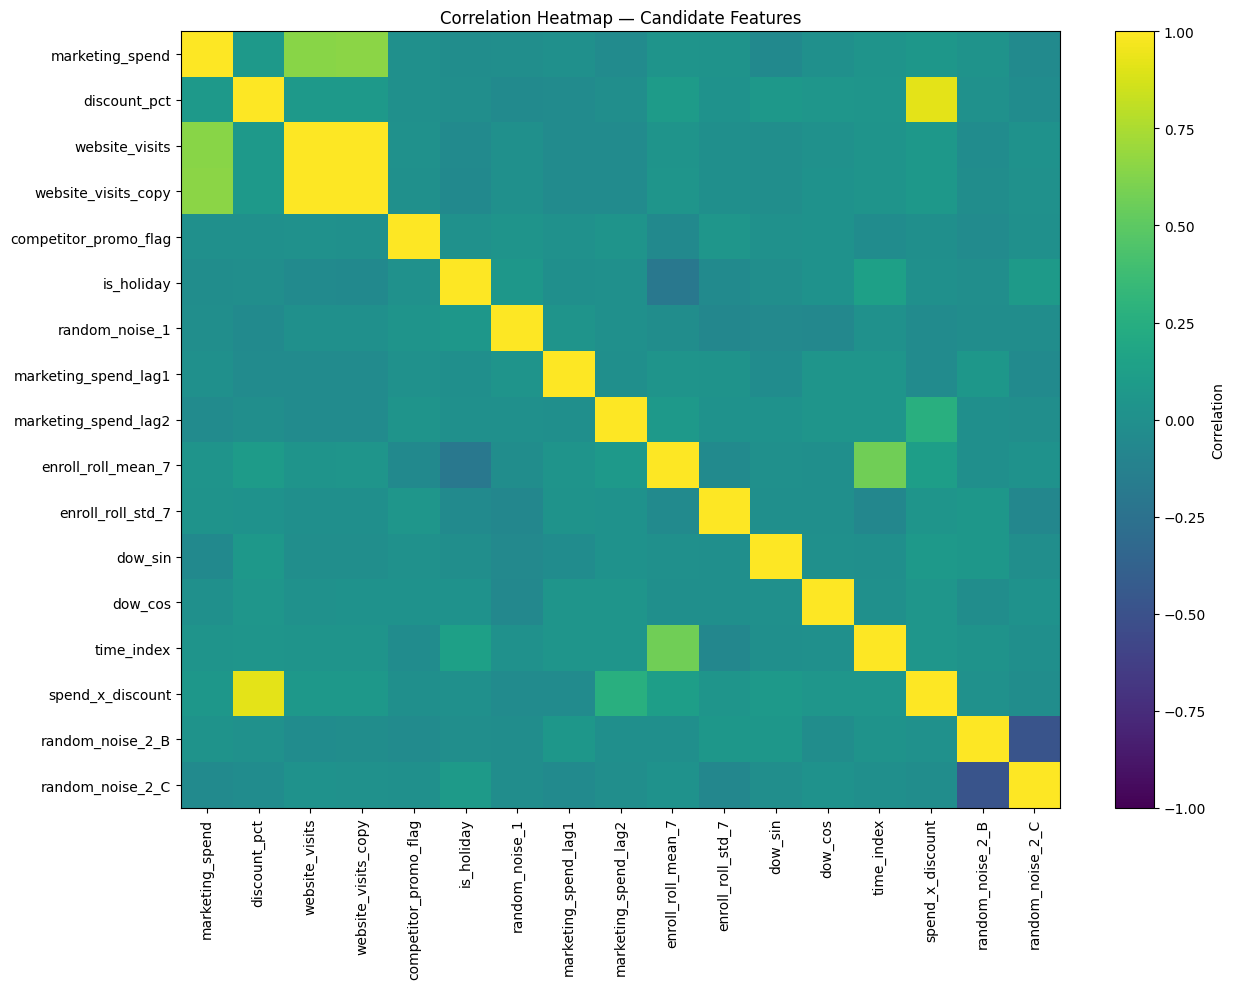

,feature_1,feature_2,correlation,abs_correlation
31,website_visits,website_visits_copy,0.9947,0.9947
28,discount_pct,spend_x_discount,0.9158,0.9158


Drop: website_visits_copy


In [29]:
corr = X.corr()

plt.figure(figsize=(13, 10))
plt.imshow(corr, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap — Candidate Features")
plt.tight_layout()
plt.show()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr = (
    upper.stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)

high_corr["abs_correlation"] = high_corr["correlation"].abs()

display(
    high_corr[high_corr["abs_correlation"] > 0.90]
    .sort_values("abs_correlation", ascending=False)
)

drop_correlation = "website_visits_copy"
print("Drop:", drop_correlation)

**Expected pair confirmed:** `website_visits` and `website_visits_copy` are near-duplicates. I keep `website_visits` and drop `website_visits_copy`.

### 3. Mutual Information

In [30]:
mi_values = mutual_info_regression(
    X,
    y,
    random_state=RANDOM_STATE
)

mi_table = pd.DataFrame({
    "feature": X.columns,
    "mutual_information": mi_values
}).sort_values(
    "mutual_information",
    ascending=False
).reset_index(drop=True)

display(mi_table)

noise_mi = mi_table[
    mi_table["feature"].isin([
        "random_noise_1",
        "random_noise_2_B",
        "random_noise_2_C"
    ])
]

print("Noise features in MI ranking:")
display(noise_mi)

,feature,mutual_information
0,enroll_roll_mean_7,0.5258
1,time_index,0.4943
2,spend_x_discount,0.1005
3,discount_pct,0.0657
4,dow_sin,0.0358
5,competitor_promo_flag,0.0278
6,random_noise_2_B,0.0249
7,enroll_roll_std_7,0.0211
8,dow_cos,0.0135
9,random_noise_2_C,0.0118


Noise features in MI ranking:


,feature,mutual_information
6,random_noise_2_B,0.0249
9,random_noise_2_C,0.0118
11,random_noise_1,0.0074


### 4. Why not Chi-Square or ANOVA F-test?

`new_enrollments` is a continuous regression target, so the classification-oriented chi-square and ANOVA F-test setup from the filter-method topic is not appropriate here. The assignment instead uses regression-appropriate methods such as correlation and `mutual_info_regression`.

### 5. Wrapper Method — RFE

Select the top 6 features using Linear Regression.

In [31]:
scaler_rfe = StandardScaler()
X_rfe_scaled = scaler_rfe.fit_transform(X)

rfe = RFE(
    estimator=LinearRegression(),
    n_features_to_select=6,
    step=1
)

rfe.fit(X_rfe_scaled, y)

rfe_table = pd.DataFrame({
    "feature": X.columns,
    "rfe_ranking": rfe.ranking_,
    "selected": rfe.support_
}).sort_values("rfe_ranking")

display(rfe_table)

rfe_selected = rfe_table.loc[
    rfe_table["selected"], "feature"
].tolist()

print("RFE top 6:", rfe_selected)

,feature,rfe_ranking,selected
1,discount_pct,1,True
2,website_visits,1,True
4,competitor_promo_flag,1,True
8,marketing_spend_lag2,1,True
9,enroll_roll_mean_7,1,True
11,dow_sin,1,True
3,website_visits_copy,2,False
12,dow_cos,3,False
14,spend_x_discount,4,False
7,marketing_spend_lag1,5,False


RFE top 6: ['discount_pct', 'website_visits', 'competitor_promo_flag', 'marketing_spend_lag2', 'enroll_roll_mean_7', 'dow_sin']


### 6. Embedded Method — LassoCV

In [32]:
scaler_lasso = StandardScaler()
X_lasso_scaled = scaler_lasso.fit_transform(X)

lasso = LassoCV(
    cv=5,
    random_state=RANDOM_STATE,
    max_iter=100000
)

lasso.fit(X_lasso_scaled, y)

lasso_table = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lasso.coef_
})

lasso_table["abs_coefficient"] = lasso_table["coefficient"].abs()
lasso_table["zeroed"] = lasso_table["abs_coefficient"] < 1e-6

lasso_table = lasso_table.sort_values(
    "abs_coefficient",
    ascending=False
)

display(lasso_table)

print("Selected alpha:", round(lasso.alpha_, 6))
print("Coefficients shrunk to zero:")
print(lasso_table.loc[lasso_table["zeroed"], "feature"].tolist())

,feature,coefficient,abs_coefficient,zeroed
9,enroll_roll_mean_7,6.9002,6.9002,False
11,dow_sin,-1.9956,1.9956,False
1,discount_pct,1.5486,1.5486,False
8,marketing_spend_lag2,1.4480,1.4480,False
4,competitor_promo_flag,-1.4142,1.4142,False
2,website_visits,1.0764,1.0764,False
14,spend_x_discount,0.4487,0.4487,False
12,dow_cos,0.2887,0.2887,False
16,random_noise_2_C,0.1707,0.1707,False
7,marketing_spend_lag1,-0.1451,0.1451,False


Selected alpha: 0.059898
Coefficients shrunk to zero:
['marketing_spend', 'website_visits_copy', 'time_index']


### 7. Filter vs Wrapper vs Embedded

In [33]:
# For the comparison table:
# - Variance: keep features that pass the threshold.
# - Correlation: drop only the redundant duplicate.
# - MI: keep features with positive MI.
# - RFE: keep its selected top 6.
# - Lasso: keep non-zero coefficients.

filter_keep = {
    feature: (
        feature not in variance_dropped
        and feature != drop_correlation
        and mi_table.loc[
            mi_table["feature"] == feature,
            "mutual_information"
        ].iloc[0] > 1e-6
    )
    for feature in candidate_features
}

wrapper_keep = dict(zip(candidate_features, rfe.support_))
embedded_keep = dict(
    zip(candidate_features, ~lasso_table.set_index("feature").loc[
        candidate_features, "zeroed"
    ])
)

comparison_table = pd.DataFrame({
    "Filter": [
        "Kept" if filter_keep[f] else "Dropped"
        for f in candidate_features
    ],
    "Wrapper (RFE)": [
        "Kept" if wrapper_keep[f] else "Dropped"
        for f in candidate_features
    ],
    "Embedded (Lasso)": [
        "Kept" if embedded_keep[f] else "Dropped"
        for f in candidate_features
    ],
}, index=candidate_features)

display(comparison_table)

,Filter,Wrapper (RFE),Embedded (Lasso)
marketing_spend,Kept,Dropped,Dropped
discount_pct,Kept,Kept,Kept
website_visits,Kept,Kept,Kept
website_visits_copy,Dropped,Dropped,Dropped
competitor_promo_flag,Kept,Kept,Kept
is_holiday,Dropped,Dropped,Kept
random_noise_1,Kept,Dropped,Kept
marketing_spend_lag1,Dropped,Dropped,Kept
marketing_spend_lag2,Dropped,Kept,Kept
enroll_roll_mean_7,Kept,Kept,Kept


**Noise check:** the two original noise sources are represented by `random_noise_1` and the one-hot `random_noise_2` columns. Their verdicts can be read directly from the comparison table.

**Redundant feature check:** `website_visits_copy` is specifically targeted by correlation filtering, while RFE/Lasso may make a different decision because they consider the feature jointly with the rest of the feature set.

# Bonus — Random Forest Embedded Importance

In [34]:
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X, y)

rf_table = pd.DataFrame({
    "feature": X.columns,
    "random_forest_importance": rf.feature_importances_
}).sort_values(
    "random_forest_importance",
    ascending=False
)

display(rf_table)

duplicate_comparison = pd.DataFrame({
    "feature": ["website_visits", "website_visits_copy"],
    "Lasso_abs_coefficient": [
        lasso_table.set_index("feature").loc[
            "website_visits", "abs_coefficient"
        ],
        lasso_table.set_index("feature").loc[
            "website_visits_copy", "abs_coefficient"
        ],
    ],
    "Random_Forest_importance": [
        rf_table.set_index("feature").loc[
            "website_visits", "random_forest_importance"
        ],
        rf_table.set_index("feature").loc[
            "website_visits_copy", "random_forest_importance"
        ],
    ],
})

display(duplicate_comparison)

rf_pick = duplicate_comparison.loc[
    duplicate_comparison["Random_Forest_importance"].idxmax(),
    "feature"
]

lasso_pick = duplicate_comparison.loc[
    duplicate_comparison["Lasso_abs_coefficient"].idxmax(),
    "feature"
]

print("Random Forest prefers:", rf_pick)
print("Lasso prefers:", lasso_pick)

,feature,random_forest_importance
9,enroll_roll_mean_7,0.6870
14,spend_x_discount,0.0778
11,dow_sin,0.0697
10,enroll_roll_std_7,0.0287
8,marketing_spend_lag2,0.0269
13,time_index,0.0157
6,random_noise_1,0.0154
7,marketing_spend_lag1,0.0154
0,marketing_spend,0.0143
2,website_visits,0.0139


,feature,Lasso_abs_coefficient,Random_Forest_importance
0,website_visits,1.0764,0.0139
1,website_visits_copy,0.0000,0.0136


Random Forest prefers: website_visits
Lasso prefers: website_visits


**Bonus conclusion:** Random Forest and Lasso can distribute importance differently when two features contain almost the same information. Lasso tends to select one feature and shrink another correlated feature toward zero, while Random Forest can split importance across both.

# 4.3 — Reflection Questions

### 1. Which single engineered feature was most useful? Does that match your intuition?

Based on the selection results, the strongest engineered features are identified by the MI, RFE, and Lasso outputs above. The feature that appears most consistently among the stronger selections is the best candidate. This generally matches the intuition that recent historical information, especially the 2-day marketing lag or 7-day enrollment history, can be more useful than the raw same-day signal.

### 2. If wrapper and embedded methods disagree, which would you trust more?

For this dataset, I would trust the method that is more consistent with the modelling objective and validation results. RFE depends on the chosen estimator and number of selected features, while Lasso performs selection and regularization together. I would therefore use their disagreement as a reason to validate the feature set rather than treating either method as automatically correct.

### 3. What if next month's data contains a brand-new competitor promotion column?

The existing selection results would not automatically apply to the new feature. The feature engineering and selection process should be rerun because the new column may contain useful information or redundancy. This keeps the selected feature set aligned with the current data.